In [1]:
from google.colab import drive
drive.mount('/content/drive') # Mount Google Drive

Mounted at /content/drive


In [2]:
!pip install -q sentence-transformers torch torchvision scikit-learn pandas openpyxl pillow tqdm matplotlib seaborn

In [3]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

# Training Part

In [5]:
IMAGE_DIR = "/content/drive/MyDrive/CPS Internship/shared task/Train/train_images"
TRAIN_EXCEL = "/content/drive/MyDrive/CPS Internship/shared task/Train/train_labels.xlsx"

In [6]:
# seeting seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [7]:
df = pd.read_excel(TRAIN_EXCEL)

print("Shape of the dataframe is : ", df.shape)
df.head()

Shape of the dataframe is :  (969, 4)


,Image_id,Text,Level1,Level2
0,0,• கர்நாடகாவில் ரஜினியின் காலா படம் வெளியா முதல...,Troll/Oppose,Troll/Oppose Against Person
1,1,Thalapathy Vijay Thiruchchi Varugai...\nThiruc...,Support/Praise,Support for person
2,2,"\n\n""அண்ண சொல்லுங்க.\n#GET OU MODI\n#GET OUT S...",Troll/Oppose,Troll/Oppose Against Party
3,3,சீமான் கவுண்டமணி மரண கலாய்\nதேங்காய அங்கேயே வை...,Troll/Oppose,Troll/Oppose Against Person
4,4,TOI - LINE OF NO CONTROL \nKAMAL HAASAN START...,Support/Praise,Support for party


In [8]:
files_in_dir = os.listdir(IMAGE_DIR)
stem_to_file = {}
for fname in files_in_dir:
    stem, ext = os.path.splitext(fname)
    stem_to_file[stem] = fname

def resolve_image_path(image_id):
    stem = str(image_id).zfill(3)   # 0 -> "000", 1 -> "001", etc.
    if stem in stem_to_file:
        return stem_to_file[stem]
    return None

df['image_path'] = df['Image_id'].apply(resolve_image_path)

df.head()

,Image_id,Text,Level1,Level2,image_path
0,0,• கர்நாடகாவில் ரஜினியின் காலா படம் வெளியா முதல...,Troll/Oppose,Troll/Oppose Against Person,000.jpg
1,1,Thalapathy Vijay Thiruchchi Varugai...\nThiruc...,Support/Praise,Support for person,001.jpg
2,2,"\n\n""அண்ண சொல்லுங்க.\n#GET OU MODI\n#GET OUT S...",Troll/Oppose,Troll/Oppose Against Party,002.jpg
3,3,சீமான் கவுண்டமணி மரண கலாய்\nதேங்காய அங்கேயே வை...,Troll/Oppose,Troll/Oppose Against Person,003.jpg
4,4,TOI - LINE OF NO CONTROL \nKAMAL HAASAN START...,Support/Praise,Support for party,004.jpg


In [9]:
print("Level1 label counts:")
print(df['Level1'].value_counts())
print()
print("Level2 label counts:")
print(df['Level2'].value_counts())

Level1 label counts:
Level1
Troll/Oppose      692
Support/Praise    277
Name: count, dtype: int64

Level2 label counts:
Level2
Troll/Oppose Against Person    545
Support for person             179
Troll/Oppose Against Party     147
Support for party               98
Name: count, dtype: int64


## Initial distribution of the data classes at leavel 1 and level 2

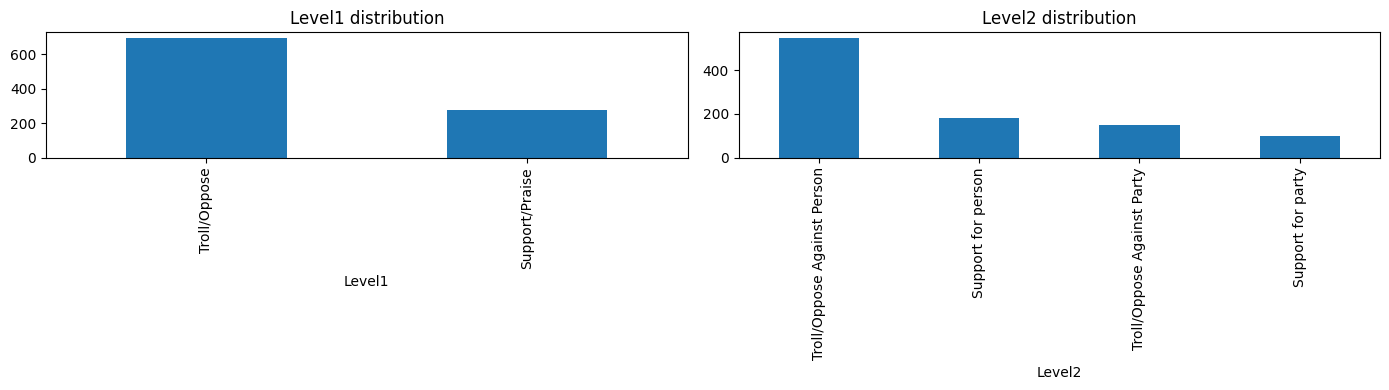

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Level1'].value_counts().plot(kind='bar', ax=axes[0], title='Level1 distribution')
df['Level2'].value_counts().plot(kind='bar', ax=axes[1], title='Level2 distribution')
axes[1].tick_params(axis='x')
plt.tight_layout()
plt.show()

In [11]:
train_df, val_df = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['Level1']
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("Train:", train_df.shape, " Val:", val_df.shape)

Train: (872, 5)  Val: (97, 5)


## Train df data distribution

Level1 label counts:
Level1
Troll/Oppose      623
Support/Praise    249
Name: count, dtype: int64

Level2 label counts:
Level2
Troll/Oppose Against Person    494
Support for person             158
Troll/Oppose Against Party     129
Support for party               91
Name: count, dtype: int64


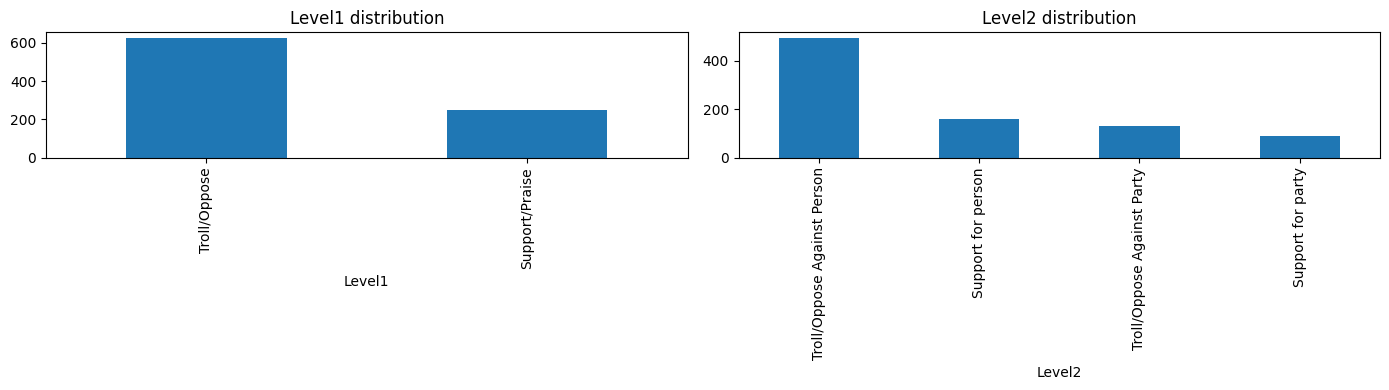

In [12]:
print("Level1 label counts:")
print(train_df['Level1'].value_counts())
print()
print("Level2 label counts:")
print(train_df['Level2'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_df['Level1'].value_counts().plot(kind='bar', ax=axes[0], title='Level1 distribution')
train_df['Level2'].value_counts().plot(kind='bar', ax=axes[1], title='Level2 distribution')
axes[1].tick_params(axis='x')
plt.tight_layout()
plt.show()

## Test df data distribution

Level1 label counts:
Level1
Troll/Oppose      69
Support/Praise    28
Name: count, dtype: int64

Level2 label counts:
Level2
Troll/Oppose Against Person    51
Support for person             21
Troll/Oppose Against Party     18
Support for party               7
Name: count, dtype: int64


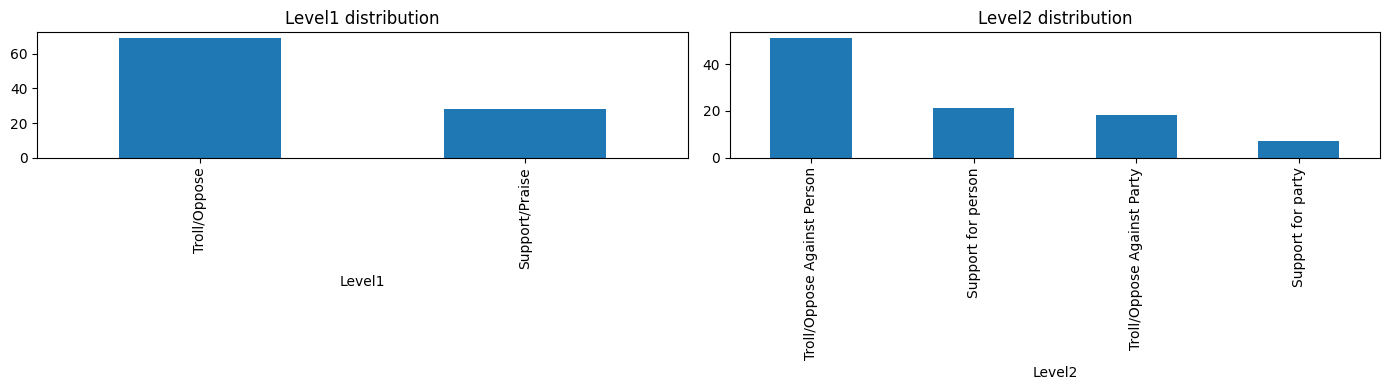

In [13]:
print("Level1 label counts:")
print(val_df['Level1'].value_counts())
print()
print("Level2 label counts:")
print(val_df['Level2'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
val_df['Level1'].value_counts().plot(kind='bar', ax=axes[0], title='Level1 distribution')
val_df['Level2'].value_counts().plot(kind='bar', ax=axes[1], title='Level2 distribution')
axes[1].tick_params(axis='x')
plt.tight_layout()
plt.show()

#### Label encoding the classes for processing

In [14]:
le1 = LabelEncoder()
le2 = LabelEncoder()

train_df['l1_id'] = le1.fit_transform(train_df['Level1'])
val_df['l1_id']   = le1.transform(val_df['Level1'])

train_df['l2_id'] = le2.fit_transform(train_df['Level2'])
val_df['l2_id']   = le2.transform(val_df['Level2'])

NUM_L1 = len(le1.classes_)
NUM_L2 = len(le2.classes_)
print("Level 1 classes:", list(le1.classes_))
print("Level 2 classes:", list(le2.classes_))

Level 1 classes: ['Support/Praise', 'Troll/Oppose']
Level 2 classes: ['Support for party', 'Support for person', 'Troll/Oppose Against Party', 'Troll/Oppose Against Person']


#### Creating embeddings for image and text

In [15]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer('BAAI/bge-m3', device=str(device))
img_model = SentenceTransformer('clip-ViT-B-32', device=str(device))

print("BAAI-BGE-M3 text embedding dimension:", text_model.get_sentence_embedding_dimension())
print("CLIP image embedding dimension:", img_model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

BAAI-BGE-M3 text embedding dimension: 1024
CLIP image embedding dimension: 512


/tmp/ipykernel_435/72097032.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("BAAI-BGE-M3 text embedding dimension:", text_model.get_sentence_embedding_dimension())
/tmp/ipykernel_435/72097032.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("CLIP image embedding dimension:", img_model.get_sentence_embedding_dimension())


In [16]:
def get_image_embeddings(paths, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(paths), batch_size)):
        batch_paths = paths[i:i+batch_size]
        imgs = [Image.open(os.path.join(IMAGE_DIR, p)).convert("RGB") for p in batch_paths]
        emb = img_model.encode(imgs, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False)
        embeddings.append(emb)
    return np.vstack(embeddings)

def get_text_embeddings(texts, batch_size=32):
    return text_model.encode(list(texts), batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False)

In [17]:
train_img_emb = get_image_embeddings(train_df['image_path'].tolist(), batch_size=32)
val_img_emb   = get_image_embeddings(val_df['image_path'].tolist(), batch_size=32)

train_txt_emb = get_text_embeddings(train_df['Text'].astype(str).tolist(), batch_size=32)
val_txt_emb   = get_text_embeddings(val_df['Text'].astype(str).tolist(), batch_size=32)

print(train_img_emb.shape, train_txt_emb.shape)

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

(872, 512) (872, 1024)


## Fusion of Image and Text embeddings

In [18]:
train_features = np.concatenate([train_img_emb, train_txt_emb], axis=1)
val_features   = np.concatenate([val_img_emb, val_txt_emb], axis=1)
print("Fused feature dim:", train_features.shape[1])

Fused feature dim: 1536


In [19]:
class MemeFeatureDataset(Dataset):
    def __init__(self, features, l1_labels, l2_labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.l1 = torch.tensor(l1_labels, dtype=torch.long)
        self.l2 = torch.tensor(l2_labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.l1[idx], self.l2[idx]

train_ds = MemeFeatureDataset(train_features, train_df['l1_id'].values, train_df['l2_id'].values)
val_ds   = MemeFeatureDataset(val_features, val_df['l1_id'].values, val_df['l2_id'].values)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

In [20]:
class HierarchicalClassifier(nn.Module):
    def __init__(self, input_dim, num_l1, num_l2, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 256),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 32),
            nn.LeakyReLU(),
        )
        self.l1_head = nn.Sequential(
            nn.Linear(32, num_l1),
        )
        # Level 2 head sees shared features + level-1 logits (conditioning)
        self.l2_head = nn.Sequential(
            nn.Linear(32 + num_l1, 16),
            nn.ReLU(),
            nn.Linear(16, num_l2),
        )

    def forward(self, x):
        shared = self.shared(x)
        l1_logits = self.l1_head(shared)
        l2_input = torch.cat([shared, l1_logits.detach()], dim=1)  # detach so L2 doesn't backprop noise into L1 head
        l2_logits = self.l2_head(l2_input)
        return l1_logits, l2_logits

input_dim = train_features.shape[1]
model = HierarchicalClassifier(input_dim, NUM_L1, NUM_L2).to(device)
model

HierarchicalClassifier(
  (shared): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=32, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
  )
  (l1_head): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
  (l2_head): Sequential(
    (0): Linear(in_features=34, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
)

In [21]:
from sklearn.utils.class_weight import compute_class_weight

l1_weights = compute_class_weight('balanced', classes=np.unique(train_df['l1_id']), y=train_df['l1_id'])
l2_weights = compute_class_weight('balanced', classes=np.unique(train_df['l2_id']), y=train_df['l2_id'])

l1_weights = torch.tensor(l1_weights, dtype=torch.float32).to(device)
l2_weights = torch.tensor(l2_weights, dtype=torch.float32).to(device)

criterion_l1 = nn.CrossEntropyLoss(weight=l1_weights)
criterion_l2 = nn.CrossEntropyLoss(weight=l2_weights)

In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

EPOCHS = 60

def evaluate(loader):
    model.eval()
    all_l1_preds, all_l1_true = [], []
    all_l2_preds, all_l2_true = [], []
    with torch.no_grad():
        for x, y1, y2 in loader:
            x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
            l1_logits, l2_logits = model(x)
            all_l1_preds.extend(l1_logits.argmax(1).cpu().numpy())
            all_l1_true.extend(y1.cpu().numpy())
            all_l2_preds.extend(l2_logits.argmax(1).cpu().numpy())
            all_l2_true.extend(y2.cpu().numpy())
    f1_l1 = f1_score(all_l1_true, all_l1_preds, average='macro')
    f1_l2 = f1_score(all_l2_true, all_l2_preds, average='macro')
    acc_l1 = accuracy_score(all_l1_true, all_l1_preds)
    acc_l2 = accuracy_score(all_l2_true, all_l2_preds)
    return f1_l1, f1_l2, acc_l1, acc_l2

best_f1 = 0
history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y1, y2 in train_loader:
        x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
        optimizer.zero_grad()
        l1_logits, l2_logits = model(x)
        loss = criterion_l1(l1_logits, y1) + criterion_l2(l2_logits, y2)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    f1_l1, f1_l2, acc_l1, acc_l2 = evaluate(val_loader)
    avg_f1 = (f1_l1 + f1_l2) / 2
    scheduler.step(avg_f1)
    history.append({"epoch": epoch+1, "loss": total_loss/len(train_loader),
                     "val_f1_l1": f1_l1, "val_f1_l2": f1_l2})

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(train_loader):.2f} "
          f"| val_F1_L1={f1_l1:.4f} val_Acc_L1={acc_l1:.4f} "
          f"| val_F1_L2={f1_l2:.4f} val_Acc_L2={acc_l2:.4f}")

    if avg_f1 > best_f1:
        best_f1 = avg_f1
        torch.save(model.state_dict(), '/content/best_model.pt')
        print("  -> saved new best model")

Epoch 1/60 | loss=1.86 | val_F1_L1=0.8660 val_Acc_L1=0.8866 | val_F1_L2=0.2830 val_Acc_L2=0.3402
  -> saved new best model
Epoch 2/60 | loss=1.36 | val_F1_L1=0.8882 val_Acc_L1=0.9072 | val_F1_L2=0.3207 val_Acc_L2=0.3711
  -> saved new best model
Epoch 3/60 | loss=1.11 | val_F1_L1=0.9212 val_Acc_L1=0.9381 | val_F1_L2=0.4662 val_Acc_L2=0.6289
  -> saved new best model
Epoch 4/60 | loss=1.04 | val_F1_L1=0.8794 val_Acc_L1=0.8969 | val_F1_L2=0.2016 val_Acc_L2=0.2268
Epoch 5/60 | loss=0.91 | val_F1_L1=0.9091 val_Acc_L1=0.9278 | val_F1_L2=0.6028 val_Acc_L2=0.7113
  -> saved new best model
Epoch 6/60 | loss=0.77 | val_F1_L1=0.8996 val_Acc_L1=0.9175 | val_F1_L2=0.5036 val_Acc_L2=0.6186
Epoch 7/60 | loss=0.72 | val_F1_L1=0.8974 val_Acc_L1=0.9175 | val_F1_L2=0.5848 val_Acc_L2=0.7320
Epoch 8/60 | loss=0.63 | val_F1_L1=0.9091 val_Acc_L1=0.9278 | val_F1_L2=0.5677 val_Acc_L2=0.5979
Epoch 9/60 | loss=0.47 | val_F1_L1=0.9212 val_Acc_L1=0.9381 | val_F1_L2=0.6484 val_Acc_L2=0.6907
  -> saved new best mod

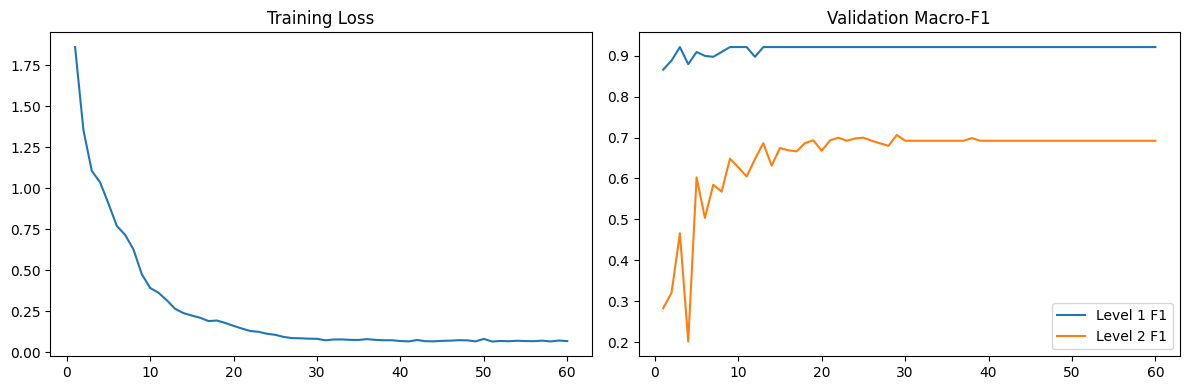

In [23]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['loss'])
axes[0].set_title('Training Loss')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_l1'], label='Level 1 F1')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_l2'], label='Level 2 F1')
axes[1].legend()
axes[1].set_title('Validation Macro-F1')
plt.tight_layout()
plt.show()

In [24]:
model.load_state_dict(torch.load('/content/best_model.pt'))
model.eval()

all_l1_preds, all_l1_true, all_l2_preds, all_l2_true = [], [], [], []
with torch.no_grad():
    for x, y1, y2 in val_loader:
        x = x.to(device)
        l1_logits, l2_logits = model(x)
        all_l1_preds.extend(l1_logits.argmax(1).cpu().numpy())
        all_l1_true.extend(y1.numpy())
        all_l2_preds.extend(l2_logits.argmax(1).cpu().numpy())
        all_l2_true.extend(y2.numpy())

print("=== Level 1: Support vs Troll ===")
print(classification_report(all_l1_true, all_l1_preds, target_names=le1.classes_))

print("=== Level 2: Target Identification ===")
print(classification_report(all_l2_true, all_l2_preds, target_names=le2.classes_))

=== Level 1: Support vs Troll ===
                precision    recall  f1-score   support

Support/Praise       0.96      0.82      0.88        28
  Troll/Oppose       0.93      0.99      0.96        69

      accuracy                           0.94        97
     macro avg       0.94      0.90      0.92        97
  weighted avg       0.94      0.94      0.94        97

=== Level 2: Target Identification ===
                             precision    recall  f1-score   support

          Support for party       0.67      0.57      0.62         7
         Support for person       0.89      0.76      0.82        21
 Troll/Oppose Against Party       0.60      0.50      0.55        18
Troll/Oppose Against Person       0.79      0.90      0.84        51

                   accuracy                           0.77        97
                  macro avg       0.74      0.68      0.71        97
               weighted avg       0.77      0.77      0.77        97



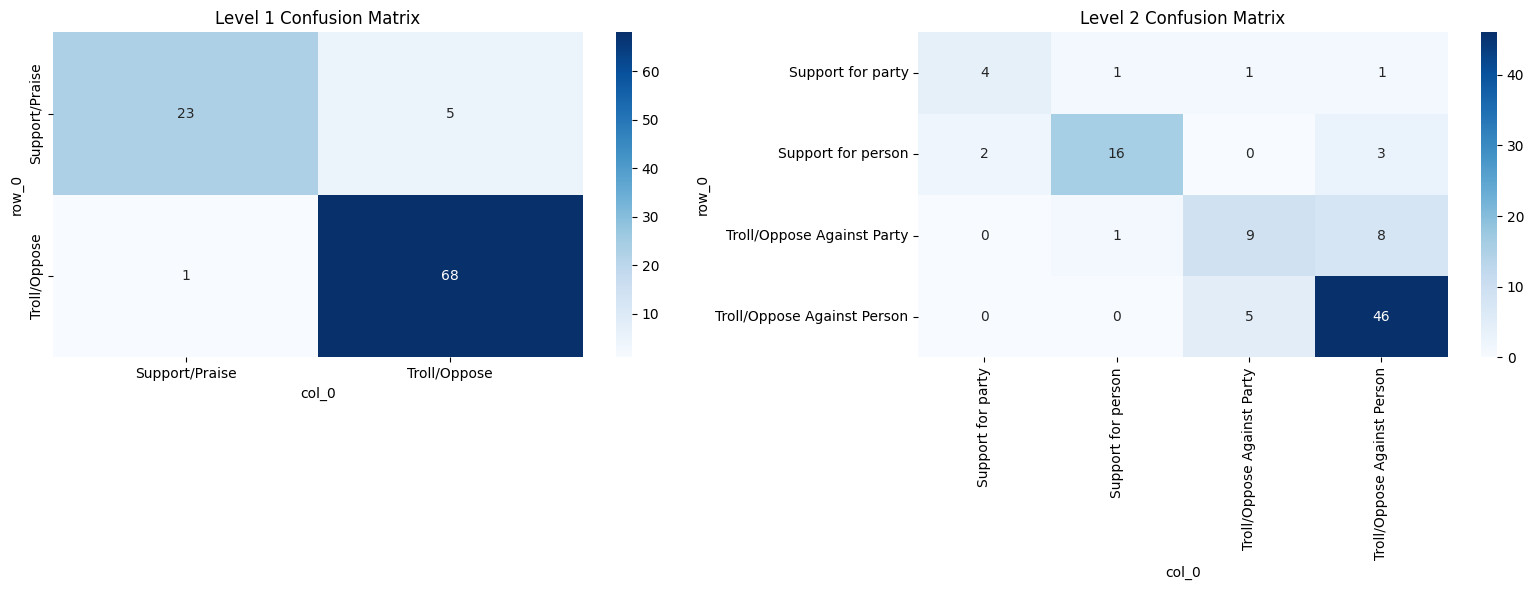

In [25]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pd.crosstab(pd.Series(all_l1_true).map(lambda i: le1.classes_[i]),
                        pd.Series(all_l1_preds).map(lambda i: le1.classes_[i])),
            annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Level 1 Confusion Matrix')

sns.heatmap(pd.crosstab(pd.Series(all_l2_true).map(lambda i: le2.classes_[i]),
                        pd.Series(all_l2_preds).map(lambda i: le2.classes_[i])),
            annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Level 2 Confusion Matrix')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# Test Part

In [32]:
IMAGE_DIR = "/content/drive/MyDrive/CPS Internship/shared task/Test/test_images"
TEST_EXCEL = "/content/drive/MyDrive/CPS Internship/shared task/Test/test-unlabelled.csv"

In [34]:
test_df = pd.read_csv(TEST_EXCEL)

print("Shape of the dataframe is : ", test_df.shape)
test_df.head()

Shape of the dataframe is :  (244, 2)


,Image_id,Text
0,0,குதிரை வேகத்தில் செயல்படும் அரசே தவிர.. குதிரை...
1,1,“உதனால் அனைத்து நாம் என்ன தீக்குச்சியா?”\nஉதயச...
2,2,வா...போ..ங்கோ...போன்றவை பாசத்தில்‌\n\nபேசுவது....
3,3,என்னிக்கு உங்க மூஞ்சில முழிச்சனோ..\nஇன்னிக்கு ...
4,4,INTERNATIONAL YOGA DAY\n\n ONE YEAR OF CAPTAIN...


In [35]:
files_in_dir = os.listdir(IMAGE_DIR)
stem_to_file = {}
for fname in files_in_dir:
    stem, ext = os.path.splitext(fname)
    stem_to_file[stem] = fname

def resolve_image_path(image_id):
    stem = str(image_id).zfill(3)   # 0 -> "000", 1 -> "001", etc.
    if stem in stem_to_file:
        return stem_to_file[stem]
    return None

test_df['image_path'] = test_df['Image_id'].apply(resolve_image_path)

test_df.head()

,Image_id,Text,image_path
0,0,குதிரை வேகத்தில் செயல்படும் அரசே தவிர.. குதிரை...,000.jpg
1,1,“உதனால் அனைத்து நாம் என்ன தீக்குச்சியா?”\nஉதயச...,001.jpg
2,2,வா...போ..ங்கோ...போன்றவை பாசத்தில்‌\n\nபேசுவது....,002.jpg
3,3,என்னிக்கு உங்க மூஞ்சில முழிச்சனோ..\nஇன்னிக்கு ...,003.jpg
4,4,INTERNATIONAL YOGA DAY\n\n ONE YEAR OF CAPTAIN...,004.jpg


In [37]:
test_img_emb   = get_image_embeddings(test_df['image_path'].tolist(), batch_size=32)

test_txt_emb   = get_text_embeddings(test_df['Text'].astype(str).tolist(), batch_size=32)

print(test_img_emb.shape, test_txt_emb.shape)

  0%|          | 0/8 [00:00<?, ?it/s]

(244, 512) (244, 1024)


In [38]:
test_features   = np.concatenate([test_img_emb, test_txt_emb], axis=1)
print("Fused feature dim:", test_features.shape[1])

Fused feature dim: 1536


In [39]:
class TestMemeFeatureDataset(Dataset):
    def __init__(self, features):
        self.features = torch.tensor(features, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]

test_ds   = TestMemeFeatureDataset(test_features)

test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False)

In [41]:
model.load_state_dict(torch.load('/content/best_model.pt'))
model.eval()

all_l1_preds, all_l2_preds = [], []
with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        l1_logits, l2_logits = model(x)
        all_l1_preds.extend(l1_logits.argmax(1).cpu().numpy())
        all_l2_preds.extend(l2_logits.argmax(1).cpu().numpy())

In [53]:
test_l1_pred = le1.inverse_transform(all_l1_preds)
test_l2_pred = le2.inverse_transform(all_l2_preds)

test_df['Level1'] = test_l1_pred
test_df['Level2'] = test_l2_pred

test_df.head()

,Image_id,Text,image_path,Level1,Level2
0,0,குதிரை வேகத்தில் செயல்படும் அரசே தவிர.. குதிரை...,000.jpg,Support/Praise,Support for person
1,1,“உதனால் அனைத்து நாம் என்ன தீக்குச்சியா?”\nஉதயச...,001.jpg,Support/Praise,Support for person
2,2,வா...போ..ங்கோ...போன்றவை பாசத்தில்‌\n\nபேசுவது....,002.jpg,Troll/Oppose,Troll/Oppose Against Person
3,3,என்னிக்கு உங்க மூஞ்சில முழிச்சனோ..\nஇன்னிக்கு ...,003.jpg,Troll/Oppose,Troll/Oppose Against Person
4,4,INTERNATIONAL YOGA DAY\n\n ONE YEAR OF CAPTAIN...,004.jpg,Troll/Oppose,Troll/Oppose Against Person


In [56]:
selected_cols = ["Image_id", "Text",  "Level1", "Level2"]

test_df[selected_cols].to_csv("CPSLab1_TamilPoliticalMeme_run1.csv", index=False)